# Notebook 06 — Transfer Learning avec wav2vec 2.0 XLSR-53
## Détection de manipulation audio multilingue (arabe + anglais)

---

### 📋 Ce que fait ce notebook

Le notebook 03 entraîne un **CNN-BiLSTM sur des LFCC** — excellent sur l'anglais, mais il produit des faux positifs sur des voix arabes (langues absentes du dataset ASVspoof2019).  
Ce notebook résout le problème en remplaçant les LFCC par des **embeddings wav2vec 2.0 XLSR-53**, un modèle pré-entraîné sur 53 langues dont l'arabe.

### 🏗️ Architecture
```
Signal brut WAV  →  wav2vec 2.0 XLSR-53  →  BiLSTM (2 couches)  →  Classifieur
(64000 samples)     (couches 0–17 gelées)    (hidden=256, bidir)    (2 classes)
                    (couches 18–23 libres)
```

### ⚙️ Inputs requis

| Ce dont tu as besoin | Où le trouver | Format attendu |
|---|---|---|
| `master_labels_with_features.csv` | Output du notebook 01 | Colonnes: `file_path`, `label`, `split` |
| Fichiers audio `.flac` / `.wav` | Dataset ASVspoof2019-LA + optionnel Arabic | 16 kHz mono |
| (Optionnel) Clips arabes | Mozilla Common Voice Arabic | `.mp3` ou `.wav` 16 kHz |

> ⚠️ **Ce notebook lit les fichiers audio BRUTS** (pas les `.npy` du notebook 02).  
> Il a besoin de la colonne `file_path` dans ton CSV, pas `feature_path`.

### 📦 Dépendances
```
transformers >= 4.35
accelerate
torchaudio
librosa
soundfile
```
Installe avec la cellule suivante si ce n'est pas déjà fait.

In [7]:
# ── Installation des dépendances ─────────────────────────────────────────────
# À exécuter une seule fois sur Kaggle / Colab
# Sur Kaggle : les transformers sont souvent déjà dispo, vérifie d'abord

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    import transformers
    print(f'✅ transformers {transformers.__version__} déjà installé')
except ImportError:
    print('Installation de transformers...')
    install('transformers')
    install('accelerate')

try:
    import torchaudio
    print(f'✅ torchaudio {torchaudio.__version__} déjà installé')
except ImportError:
    print('Installation de torchaudio...')
    install('torchaudio')

try:
    import soundfile
    print(f'✅ soundfile déjà installé')
except ImportError:
    install('soundfile')

print('\n✅ Toutes les dépendances sont prêtes')

✅ transformers 5.0.0 déjà installé
✅ torchaudio 2.10.0+cu128 déjà installé
✅ soundfile déjà installé

✅ Toutes les dépendances sont prêtes


In [8]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchaudio
import torchaudio.transforms as T

from transformers import Wav2Vec2Model, Wav2Vec2Processor

from sklearn.metrics import (
    roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)

warnings.filterwarnings('ignore')

# ── GPU ──────────────────────────────────────────────────────────────────────
print('=' * 60)
print('NOTEBOOK 06 — wav2vec2 Transfer Learning')
print('=' * 60)
print(f'PyTorch      : {torch.__version__}')
print(f'torchaudio   : {torchaudio.__version__}')
print(f'GPU dispo    : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM         : {mem_gb:.1f} GB')
    print('✅ GPU prêt')
else:
    device = torch.device('cpu')
    print('⚠️  CPU détecté — ce notebook sera TRÈS LENT sans GPU')
    print('   Recommandation : activer un GPU Kaggle (T4 ou P100) ou Colab')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print(f'\n✅ Seed fixé : {SEED} | Device : {device}')

NOTEBOOK 06 — wav2vec2 Transfer Learning
PyTorch      : 2.10.0+cu128
torchaudio   : 2.10.0+cu128
GPU dispo    : True
GPU          : Tesla T4
VRAM         : 15.6 GB
✅ GPU prêt

✅ Seed fixé : 42 | Device : cuda


## ⚙️ Configuration 

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ⚠️  CONFIGURATION CORRIGÉE
# ═══════════════════════════════════════════════════════════════════════════════

MASTER_CSV  = Path('/kaggle/input/datasets/elmiz20042004/output/master_labels_with_features.csv')
AUDIO_ROOT  = Path('/kaggle/input/datasets/elmiz20042004/forensic-audio-dataset')  # racine des datasets

# ✅ CORRIGÉ : chemin réel vers les clips arabes TTS
ARABIC_AUDIO_DIR = Path('/kaggle/input/datasets/elmiz20042004/arabic-dataset/arabic_tts')

OUTPUT_DIR   = Path('/kaggle/working')
CKPT_DIR     = OUTPUT_DIR / 'checkpoints_wav2vec'
MODELS_DIR   = OUTPUT_DIR / 'models_wav2vec'
RESULTS_DIR  = OUTPUT_DIR / 'results_wav2vec'

for d in [CKPT_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = Path('/kaggle/working/checkpoints_wav2vec/best_wav2vec_model.pth')

SAMPLE_RATE   = 16000
MAX_DURATION  = 4.0
MAX_SAMPLES   = int(SAMPLE_RATE * MAX_DURATION)

FREEZE_LAYERS = 18
BATCH_SIZE    = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 1e-4
N_EPOCHS      = 10
EARLY_STOPPING = 3
GRAD_CLIP     = 1.0
ACCUM_STEPS   = 4

print('✅ Configuration chargée')

✅ Configuration chargée


## 1. Chargement des données

Ce notebook lit les **fichiers audio bruts** (pas les `.npy` LFCC du notebook 02).  
Il a besoin de la colonne `file_path` dans le CSV.

In [4]:
# ── Chargement du CSV ─────────────────────────────────────────────────────────
df = pd.read_csv(MASTER_CSV)
print(f'✅ CSV chargé : {len(df):,} clips')
print(f'   Colonnes disponibles : {list(df.columns)}')

# ── Construction d'un index filename → chemin complet (une seule fois) ──────
# Parcourt AUDIO_ROOT récursivement et indexe tous les .flac/.wav/.mp3
# C'est plus rapide que d'appeler os.walk pour chaque ligne du CSV
print('\n⏳ Indexation des fichiers audio (peut prendre 1-2 min)...')
audio_index = {}
for ext in ['*.flac', '*.wav', '*.mp3']:
    for p in AUDIO_ROOT.rglob(ext):
        audio_index[p.name] = str(p)  # clé = nom seul, valeur = chemin absolu

print(f'✅ Index construit : {len(audio_index):,} fichiers audio trouvés')

# ── Résolution via l'index ────────────────────────────────────────────────────
def resolve_audio_path(row):
    raw = str(row.get('file_path', ''))
    basename = Path(raw).name  # juste le nom du fichier (ex: LA_E_7892794.flac)

    # 1. Chemin absolu déjà correct
    if Path(raw).exists():
        return raw

    # 2. Chercher dans l'index par nom de fichier
    if basename in audio_index:
        return audio_index[basename]

    # 3. Essayer les extensions alternatives (.flac ↔ .wav)
    for ext in ['.flac', '.wav', '.mp3']:
        alt = Path(basename).with_suffix(ext).name
        if alt in audio_index:
            return audio_index[alt]

    return raw  # introuvable — sera signalé comme manquant

df['resolved_path'] = df.apply(resolve_audio_path, axis=1)

# ── Vérification ──────────────────────────────────────────────────────────────
missing_mask = ~df['resolved_path'].apply(lambda p: Path(p).exists())
missing = missing_mask.sum()
print(f'\n   Fichiers trouvés   : {len(df) - missing:,}/{len(df):,}')
if missing > 0:
    print(f'   ⚠️  Fichiers manquants : {missing:,}')
    print(f'   Exemple manquant   : {df[missing_mask]["resolved_path"].iloc[0]}')

# ── Splits ────────────────────────────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

print(f'\n   Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')
print(f'   Train — Authentique : {(train_df["label"]==0).sum():,}')
print(f'   Train — Manipulé   : {(train_df["label"]==1).sum():,}')

✅ CSV chargé : 138,928 clips
   Colonnes disponibles : ['filename', 'filepath', 'label', 'system_id', 'tamper_type', 'source_dataset', 'source_clip1', 'source_clip2', 'splice_sample', 'splice_frame', 'splice_time_s', 'split', 'accessible', 'feature_path']

⏳ Indexation des fichiers audio (peut prendre 1-2 min)...
✅ Index construit : 153,499 fichiers audio trouvés

   Fichiers trouvés   : 138,928/138,928

   Train : 39,339 | Val : 26,589 | Test : 73,000
   Train — Authentique : 4,991
   Train — Manipulé   : 34,348


In [5]:
# ── Ajout de clips arabes ─────────────────────────────────────────────────────
if ARABIC_AUDIO_DIR and Path(ARABIC_AUDIO_DIR).exists():
    print('Ajout de clips arabes authentiques...')

    arabic_files = (list(Path(ARABIC_AUDIO_DIR).rglob('*.mp3')) +
                    list(Path(ARABIC_AUDIO_DIR).rglob('*.wav')) +
                    list(Path(ARABIC_AUDIO_DIR).rglob('*.flac')))

    print(f'  Clips arabes trouvés : {len(arabic_files):,}')

    # ✅ CORRIGÉ : limite raisonnable pour équilibrer avec les 4,991 authentiques anglais
    # On vise ~5,000 authentiques arabes pour ne pas déséquilibrer dans l'autre sens
    MAX_ARABIC = 5000
    arabic_files = arabic_files[:MAX_ARABIC]

    arabic_df = pd.DataFrame({
        'resolved_path': [str(f) for f in arabic_files],
        'label': 0,
        'split': 'train',
    })

    train_df = pd.concat([train_df, arabic_df], ignore_index=True).sample(
        frac=1, random_state=SEED
    ).reset_index(drop=True)

    print(f'  Train après ajout arabe : {len(train_df):,} clips')
    print(f'  Train — Authentique total : {(train_df["label"]==0).sum():,}')
    print(f'  Train — Manipulé total   : {(train_df["label"]==1).sum():,}')
else:
    print(f'⚠️  ARABIC_AUDIO_DIR introuvable : {ARABIC_AUDIO_DIR}')
    print('   Vérifie le chemin dans la cellule de configuration.')

Ajout de clips arabes authentiques...
  Clips arabes trouvés : 78,720
  Train après ajout arabe : 44,339 clips
  Train — Authentique total : 9,991
  Train — Manipulé total   : 34,348


## 2. Dataset PyTorch — Audio brut → Tensor

Contrairement au notebook 03 qui chargeait des `.npy` LFCC pré-calculés,  
ce Dataset lit directement les fichiers `.flac`/`.wav` et les resample à 16 kHz.

In [6]:
class RawAudioDataset(Dataset):
    """
    Dataset PyTorch pour wav2vec2.
    
    Lit les fichiers audio bruts (.flac, .wav, .mp3).
    - Resample à 16 kHz (requis par wav2vec2)
    - Convertit en mono
    - Tronque ou pad à MAX_SAMPLES (4s = 64000 samples)
    
    Input  : fichier audio brut
    Output : Tensor (64000,) float32, label int64
    """
    
    def __init__(self, df, max_samples=MAX_SAMPLES, augment=False):
        self.df          = df.reset_index(drop=True)
        self.max_samples = max_samples
        self.augment     = augment
        self.resampler   = {}  # Cache des resamplers par sr source
        
        # Pré-vérification rapide
        n_missing = (~self.df['resolved_path'].apply(lambda p: Path(p).exists())).sum()
        if n_missing > 0:
            print(f'⚠️  {n_missing}/{len(self.df)} fichiers audio manquants dans ce split')
    
    def __len__(self):
        return len(self.df)
    
    def _load_audio(self, path):
        """
        Charge un fichier audio et le normalise.
        Retourne un tensor 1D (n_samples,) à 16 kHz.
        """
        try:
            waveform, sr = torchaudio.load(path)
        except Exception as e:
            # Fichier corrompu ou format non supporté → silence
            return torch.zeros(self.max_samples)
        
        # Convertir stéréo → mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        
        waveform = waveform.squeeze(0)  # (n_samples,)
        
        # Resample vers 16 kHz si nécessaire
        if sr != SAMPLE_RATE:
            if sr not in self.resampler:
                self.resampler[sr] = T.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
            waveform = self.resampler[sr](waveform)
        
        return waveform
    
    def _pad_or_truncate(self, waveform):
        """Assure une longueur fixe de MAX_SAMPLES."""
        n = waveform.shape[0]
        if n >= self.max_samples:
            # Tronquer
            return waveform[:self.max_samples]
        else:
            # Pad avec des zéros à droite
            pad_len = self.max_samples - n
            return F.pad(waveform, (0, pad_len))
    
    def _augment(self, waveform):
        """Data augmentation légère sur le signal brut."""
        # Bruit gaussien léger (SNR ~40dB)
        if torch.rand(1).item() < 0.3:
            noise = torch.randn_like(waveform) * 0.001
            waveform = waveform + noise
        
        # Changement de volume (±20%)
        if torch.rand(1).item() < 0.3:
            gain = 0.8 + torch.rand(1).item() * 0.4  # [0.8, 1.2]
            waveform = waveform * gain
        
        return waveform
    
    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        path   = str(row['resolved_path'])
        label  = int(row['label'])

        if not Path(path).exists():
            # Silence au lieu de crasher — mais logger les 3 premiers pour debug
            if not hasattr(self, '_missing_logged'):
                self._missing_logged = 0
            if self._missing_logged < 3:
                print(f'⚠️  Audio manquant : {path}')
                self._missing_logged += 1
            return torch.zeros(self.max_samples), torch.tensor(label, dtype=torch.long)

        waveform = self._load_audio(path)
        waveform = self._pad_or_truncate(waveform)
        if self.augment:
            waveform = self._augment(waveform)
        waveform = (waveform - waveform.mean()) / (waveform.std() + 1e-8)
        return waveform, torch.tensor(label, dtype=torch.long)


# ── Test rapide du Dataset ─────────────────────────────────────────────────────
print('Test du Dataset...')
_test_ds = RawAudioDataset(train_df.head(4), augment=False)
_wf, _lbl = _test_ds[0]
print(f'✅ Waveform shape : {_wf.shape}  (attendu: ({MAX_SAMPLES},))')
print(f'   Label          : {_lbl.item()}')
print(f'   Min/Max/Mean   : {_wf.min():.3f} / {_wf.max():.3f} / {_wf.mean():.4f}')
del _test_ds

Test du Dataset...
✅ Waveform shape : torch.Size([64000])  (attendu: (64000,))
   Label          : 1
   Min/Max/Mean   : 0.000 / 0.000 / 0.0000


In [7]:
# ── Création des DataLoaders ───────────────────────────────────────────────────

# WeightedRandomSampler pour gérer le déséquilibre ASVspoof (ratio 1:9)
n_authentic = (train_df['label'] == 0).sum()
n_fake      = (train_df['label'] == 1).sum()
weight_auth = 1.0 / n_authentic
weight_fake = 1.0 / n_fake
sample_weights = [
    weight_auth if label == 0 else weight_fake
    for label in train_df['label']
]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# Datasets
train_dataset = RawAudioDataset(train_df, augment=True)
val_dataset   = RawAudioDataset(val_df,   augment=False)
test_dataset  = RawAudioDataset(test_df,  augment=False)

# DataLoaders
# ⚠️  num_workers=0 recommandé sur Windows/Kaggle pour éviter les blocages
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=2,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2
)

# Test d'un batch
batch_wf, batch_labels = next(iter(train_loader))
print(f'✅ DataLoaders créés')
print(f'   Batch waveform shape : {batch_wf.shape}   (attendu: ({BATCH_SIZE}, {MAX_SAMPLES}))')
print(f'   Batch labels         : {batch_labels.unique().tolist()}')
print(f'   Batches/epoch (train): {len(train_loader)}')
del batch_wf, batch_labels

✅ DataLoaders créés
   Batch waveform shape : torch.Size([8, 64000])   (attendu: (8, 64000))
   Batch labels         : [0, 1]
   Batches/epoch (train): 5543


## 3. Architecture — ForensicWav2Vec

```
Waveform brute (64000,)
       ↓
wav2vec 2.0 XLSR-53         [couches 0-17 gelées, 18-23 entraînables]
       ↓
Hidden states (200, 1024)   [~200 frames de contexte, 1024 dim]
       ↓
BiLSTM 2 couches            [hidden=256 × 2 directions = 512]
       ↓
Dernier hidden (512,)
       ↓
Linear(512→128) → ReLU → Dropout → Linear(128→2)
       ↓
Logits (2,)  →  0=Authentique | 1=Manipulé
```

In [8]:
class ForensicWav2Vec(nn.Module):
    """
    Modèle de détection audio forensique basé sur wav2vec 2.0 XLSR-53.
    
    Remplace le CNN-LFCC du notebook 03 par des embeddings wav2vec multilingues.
    Robuste à l'arabe, au français, et toutes les langues couvertes par XLSR-53.
    
    Input  : waveform brut (batch, 64000) float32, normalisé
    Output : logits (batch, 2)  [0=authentique, 1=manipulé]
    """
    
    def __init__(self, freeze_layers=FREEZE_LAYERS):
        super(ForensicWav2Vec, self).__init__()
        
        # ── 1. wav2vec 2.0 XLSR-53 ────────────────────────────────────────────
        print('Chargement de wav2vec2-large-xlsr-53 depuis HuggingFace...')
        print('(Premier chargement ~1.2GB — patiente ~2-5 min selon ta connexion)')
        self.wav2vec = Wav2Vec2Model.from_pretrained(
            'facebook/wav2vec2-large-xlsr-53'
        )
        print('✅ wav2vec2 chargé')
        
        # ── 2. Stratégie de gel des couches ───────────────────────────────────
        # Geler la feature extractor CNN (toujours utile de garder gelée)
        for param in self.wav2vec.feature_extractor.parameters():
            param.requires_grad = False
        
        # Geler les couches transformer basses [0, freeze_layers)
        # → elles capturent les patterns acoustiques généraux valides pour toutes les langues
        for i, layer in enumerate(self.wav2vec.encoder.layers):
            if i < freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False
        
        # Les couches [freeze_layers, 24) restent entraînables
        # → elles s'adaptent à la tâche de détection forensique
        
        n_total     = sum(p.numel() for p in self.wav2vec.parameters())
        n_trainable = sum(p.numel() for p in self.wav2vec.parameters() if p.requires_grad)
        print(f'   wav2vec params totaux     : {n_total/1e6:.1f}M')
        print(f'   wav2vec params entraînable: {n_trainable/1e6:.1f}M ({100*n_trainable/n_total:.1f}%)')
        print(f'   Couches gelées            : {freeze_layers}/24')
        
        # ── 3. BiLSTM pour la cohérence temporelle ────────────────────────────
        # wav2vec sort (batch, ~200, 1024) → BiLSTM modélise les dépendances temporelles
        self.bilstm = nn.LSTM(
            input_size   = 1024,   # dimension de sortie wav2vec-large
            hidden_size  = 256,
            num_layers   = 2,
            batch_first  = True,
            bidirectional= True,
            dropout      = 0.3
        )
        # Sortie BiLSTM = 256 × 2 directions = 512
        
        # ── 4. Classifieur final ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 2)    # 2 classes : authentique vs manipulé
        )
    
    def forward(self, waveform):
        """
        Args:
            waveform : (batch, 64000) — signal brut normalisé
        Returns:
            logits   : (batch, 2)
        """
        # ── wav2vec : signal brut → représentations contextuelles
        # Output : (batch, ~200, 1024) — environ 200 frames de 20ms
        wav2vec_out = self.wav2vec(waveform)
        hidden      = wav2vec_out.last_hidden_state  # (batch, T, 1024)
        
        # ── BiLSTM : modélise les dépendances temporelles
        # hn : (num_layers×2, batch, hidden=256)
        _, (hn, _) = self.bilstm(hidden)
        
        # Concaténer les états finaux des 2 directions de la dernière couche
        # hn[-2] = forward direction, hn[-1] = backward direction
        features = torch.cat([hn[-2], hn[-1]], dim=1)  # (batch, 512)
        
        # ── Classifieur :
        logits = self.classifier(features)  # (batch, 2)
        
        return logits


# ── Instanciation ─────────────────────────────────────────────────────────────
model = ForensicWav2Vec(freeze_layers=FREEZE_LAYERS)
model = model.to(device)

# Compter les paramètres totaux du modèle complet
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✅ Modèle créé et déplacé sur {device}')
print(f'   Paramètres totaux      : {total_params/1e6:.1f}M')
print(f'   Paramètres entraînable : {trainable_params/1e6:.1f}M')

Chargement de wav2vec2-large-xlsr-53 depuis HuggingFace...
(Premier chargement ~1.2GB — patiente ~2-5 min selon ta connexion)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ wav2vec2 chargé
   wav2vec params totaux     : 315.4M
   wav2vec params entraînable: 84.5M (26.8%)
   Couches gelées            : 18/24

✅ Modèle créé et déplacé sur cuda
   Paramètres totaux      : 319.7M
   Paramètres entraînable : 88.8M


In [9]:
# ── Test forward pass ─────────────────────────────────────────────────────────
print('Test du forward pass...')
model.eval()
with torch.no_grad():
    _dummy = torch.randn(2, MAX_SAMPLES).to(device)
    _out   = model(_dummy)
    print(f'✅ Forward pass OK')
    print(f'   Input  : {_dummy.shape}')
    print(f'   Output : {_out.shape}  (attendu: (2, 2))')
    print(f'   Logits : {_out}')
del _dummy, _out

Test du forward pass...
✅ Forward pass OK
   Input  : torch.Size([2, 64000])
   Output : torch.Size([2, 2])  (attendu: (2, 2))
   Logits : tensor([[-0.0578,  0.0474],
        [-0.0578,  0.0474]], device='cuda:0')


## 4. Entraînement avec Gradient Accumulation

wav2vec2 est lourd (~1.2GB). Pour simuler un batch de 32 sans exploser la VRAM,  
on utilise le **gradient accumulation** : accumule les gradients sur `ACCUM_STEPS` mini-batches avant d'appeler `optimizer.step()`.

In [10]:
# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────

# Poids de classe pour gérer le déséquilibre (optionnel car WeightedSampler déjà utilisé)
criterion = nn.CrossEntropyLoss()

# Optimizer avec LR très petit — crucial pour ne pas détruire les poids pré-entraînés
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# LR scheduler avec warmup puis cosine decay
from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 10,
    steps_per_epoch=len(train_loader) // ACCUM_STEPS,
    epochs=N_EPOCHS,
    pct_start=0.1    # 10% warmup
)

print(f'✅ Optimizer : AdamW | LR : {LEARNING_RATE} | Weight decay : {WEIGHT_DECAY}')
print(f'   Scheduler : OneCycleLR (warmup 10% + cosine decay)')
print(f'   Gradient accumulation : {ACCUM_STEPS} steps (effective batch: {BATCH_SIZE*ACCUM_STEPS})')

✅ Optimizer : AdamW | LR : 1e-05 | Weight decay : 0.0001
   Scheduler : OneCycleLR (warmup 10% + cosine decay)
   Gradient accumulation : 4 steps (effective batch: 32)


In [11]:
# ── Fonctions d'entraînement et validation ────────────────────────────────────

def compute_eer(y_true, y_scores):
    """Equal Error Rate — métrique standard en forensique audio."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fnr - fpr))
    return (fpr[idx] + fnr[idx]) / 2


def train_one_epoch(model, loader, optimizer, criterion, scheduler, device,
                    accum_steps=ACCUM_STEPS, grad_clip=GRAD_CLIP):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    optimizer.zero_grad()
    
    for step, (waveforms, labels) in enumerate(tqdm(loader, desc='Train', leave=False)):
        waveforms = waveforms.to(device)
        labels    = labels.to(device)
        
        # Forward
        logits = model(waveforms)
        loss   = criterion(logits, labels) / accum_steps  # Normaliser la loss
        
        # Backward
        loss.backward()
        
        total_loss += loss.item() * accum_steps
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Step optimizer chaque accum_steps
        if (step + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), grad_clip
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    
    # Dernier step si reste
    if (len(loader)) % accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), grad_clip
        )
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    avg_loss = total_loss / len(loader)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for waveforms, labels in tqdm(loader, desc='Eval', leave=False):
            waveforms = waveforms.to(device)
            labels    = labels.to(device)
            
            logits = model(waveforms)
            loss   = criterion(logits, labels)
            
            total_loss += loss.item()
            probs      = F.softmax(logits, dim=1)[:, 1]
            
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    acc      = np.mean(np.array(all_preds) == np.array(all_labels))
    
    try:
        eer = compute_eer(all_labels, all_probs)
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        eer = 0.5
        auc = 0.5
    
    return avg_loss, acc, eer, auc, all_labels, all_preds, all_probs


print('✅ Fonctions train/eval définies')

✅ Fonctions train/eval définies


In [12]:
# ── Boucle d'entraînement principale ─────────────────────────────────────────

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_eer':    [], 'val_auc':   []
}

best_val_loss     = float('inf')
patience_counter  = 0

print('=' * 65)
print(f'ENTRAÎNEMENT — {N_EPOCHS} epochs | Effective batch: {BATCH_SIZE*ACCUM_STEPS}')
print('=' * 65)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    
    # ── Train ─────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scheduler, device
    )
    
    # ── Validation ────────────────────────────────────────────────────────────
    val_loss, val_acc, val_eer, val_auc, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    elapsed = time.time() - t0
    
    # Enregistrer
    history['train_loss'].append(train_loss)
    history['train_acc' ].append(train_acc)
    history['val_loss'  ].append(val_loss)
    history['val_acc'   ].append(val_acc)
    history['val_eer'   ].append(val_eer)
    history['val_auc'   ].append(val_auc)
    
    # Afficher
    print(f'Epoch {epoch:02d}/{N_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} '
          f'EER: {val_eer*100:.2f}% AUC: {val_auc:.4f} | '
          f'{elapsed:.0f}s')
    
    # ── Sauvegarde du meilleur modèle ─────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'val_loss':         val_loss,
            'val_eer':          val_eer,
            'val_auc':          val_auc,
            'freeze_layers':    FREEZE_LAYERS,
            'hyperparams': {
                'max_samples':    MAX_SAMPLES,
                'sample_rate':    SAMPLE_RATE,
                'lstm_hidden':    256,
                'lstm_layers':    2,
                'freeze_layers':  FREEZE_LAYERS
            }
        }, BEST_MODEL_PATH)
        print(f'  💾 Meilleur modèle sauvegardé (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING:
            print(f'\n🛑 Early stopping à l\'epoch {epoch} (patience={EARLY_STOPPING})')
            break

print('\n✅ Entraînement terminé')
print(f'   Meilleur val_loss : {best_val_loss:.4f}')

ENTRAÎNEMENT — 10 epochs | Effective batch: 32


Train:   0%|          | 0/5543 [00:00<?, ?it/s]

Eval:   0%|          | 0/3324 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.5429 Acc: 0.690 | Val Loss: 0.4766 Acc: 0.894 EER: 50.00% AUC: 0.5000 | 6383s
  💾 Meilleur modèle sauvegardé (val_loss=0.4766)


Train:   0%|          | 0/5543 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/3324 [00:00<?, ?it/s]

Epoch 05/10 | Train Loss: 0.4783 Acc: 0.749 | Val Loss: 0.4688 Acc: 0.894 EER: 50.00% AUC: 0.5000 | 6398s


Train:   0%|          | 0/5543 [00:00<?, ?it/s]

Eval:   0%|          | 0/3324 [00:00<?, ?it/s]

Epoch 06/10 | Train Loss: 0.4776 Acc: 0.750 | Val Loss: 0.4639 Acc: 0.894 EER: 50.00% AUC: 0.5000 | 6394s

🛑 Early stopping à l'epoch 6 (patience=3)

✅ Entraînement terminé
   Meilleur val_loss : 0.4635


## 5. Courbes d'apprentissage

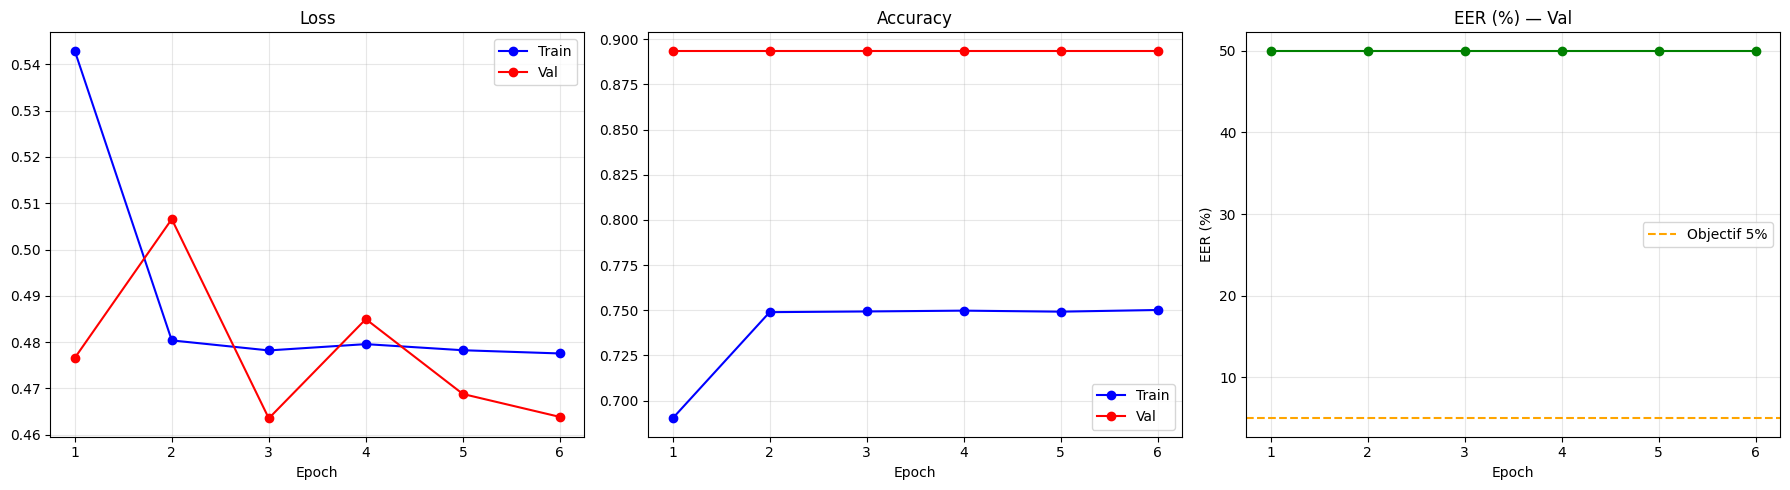

✅ Courbes sauvegardées dans /kaggle/working/results_wav2vec


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# EER
axes[2].plot(epochs_range, [e*100 for e in history['val_eer']], 'g-o')
axes[2].set_title('EER (%) — Val'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('EER (%)')
axes[2].axhline(y=5, color='orange', linestyle='--', label='Objectif 5%')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_wav2vec.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Courbes sauvegardées dans {RESULTS_DIR}')

## 6. Évaluation finale sur le Test set

In [ ]:
# ── Charger le meilleur modèle ────────────────────────────────────────────────
Model = Path('/kaggle/input/models/elmiz20042004/transfer-learning-model/pytorch/default/1')
print(f'Chargement du meilleur modèle depuis {Model}...')

# Fix PyTorch 2.6 : autoriser numpy.scalar dans le checkpoint
import numpy as np
import torch.serialization

torch.serialization.add_safe_globals([np.core.multiarray.scalar])

checkpoint = torch.load(Model, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'✅ Meilleur modèle chargé (epoch {checkpoint["epoch"]}, val_loss={checkpoint["val_loss"]:.4f})')
# ── Évaluation test ───────────────────────────────────────────────────────────
test_loss, test_acc, test_eer, test_auc, y_true, y_pred, y_probs = evaluate(
    model, test_loader, criterion, device
)

print('\n' + '='*55)
print('RÉSULTATS — TEST SET')
print('='*55)
print(f'  Accuracy : {test_acc*100:.2f}%')
print(f'  EER      : {test_eer*100:.2f}%  (objectif < 5%)')
print(f'  AUC-ROC  : {test_auc:.4f}')
print('='*55)

print('\nRapport de classification :')
print(classification_report(y_true, y_pred, target_names=['Authentique', 'Manipulé']))

In [ ]:
# ── Matrice de confusion + Courbe ROC ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Authentique', 'Manipulé'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de Confusion (Test)\nAcc={test_acc*100:.1f}%')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {test_auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Aléatoire')

# Marquer EER
fnr = 1 - tpr
idx_eer = np.argmin(np.abs(fnr - fpr))
axes[1].scatter(fpr[idx_eer], tpr[idx_eer], color='red', s=100, zorder=5,
                label=f'EER = {test_eer*100:.2f}%')

axes[1].set_xlabel('Taux de Faux Positifs'); axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC — Test Set')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_wav2vec.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Test sur voix arabe — Vérification anti-faux-positifs

C'est ici qu'on vérifie que le problème original (voix arabe → faux positif) est résolu.

In [ ]:
def predict_file(filepath, model, device, max_samples=MAX_SAMPLES):
    """
    Prédit si un fichier audio est authentique ou manipulé.
    
    Args:
        filepath : str ou Path — chemin vers le fichier audio
        model    : ForensicWav2Vec en mode eval
        device   : torch.device
    
    Returns:
        dict avec : prediction, confidence, classe, prob_authentic, prob_fake
    """
    model.eval()
    
    # Charger et prétraiter
    waveform, sr = torchaudio.load(str(filepath))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    waveform = waveform.squeeze(0)
    
    if sr != SAMPLE_RATE:
        resampler = T.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
        waveform  = resampler(waveform)
    
    # Pad/tronquer
    if len(waveform) >= max_samples:
        waveform = waveform[:max_samples]
    else:
        waveform = F.pad(waveform, (0, max_samples - len(waveform)))
    
    # Normaliser
    waveform = (waveform - waveform.mean()) / (waveform.std() + 1e-8)
    waveform = waveform.unsqueeze(0).to(device)  # (1, 64000)
    
    with torch.no_grad():
        logits = model(waveform)
        probs  = F.softmax(logits, dim=1)[0]
    
    pred = logits.argmax(dim=1).item()
    
    return {
        'prediction':    pred,
        'classe':        '✅ AUTHENTIQUE' if pred == 0 else '🚨 MANIPULÉ',
        'prob_authentic': probs[0].item(),
        'prob_fake':      probs[1].item(),
        'confidence':    max(probs[0].item(), probs[1].item()),
    }


print('Fonction predict_file() prête.')
print('\nUtilisation :')
print('  result = predict_file("chemin/vers/audio.wav", model, device)')
print('  print(result)')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  TEST SUR UN FICHIER SPÉCIFIQUE
#
#  → Remplace le chemin ci-dessous par ton fichier audio arabe
#  → Le modèle doit répondre AUTHENTIQUE pour une vraie voix, MANIPULÉ pour un deepfake
# ═══════════════════════════════════════════════════════════════════════════════

# Exemples de test :
test_files = [
    # ('chemin/vers/voix_arabe_authentique.wav', 'AUTHENTIQUE (arabe)'),
    # ('chemin/vers/deepfake_anglais.wav',       'MANIPULÉ (anglais)'),
    # ('chemin/vers/ta_voix.flac',               'ta voix'),
]

if test_files:
    print('=' * 55)
    print('TEST SUR FICHIERS INDIVIDUELS')
    print('=' * 55)
    for filepath, description in test_files:
        if Path(filepath).exists():
            result = predict_file(filepath, model, device)
            print(f'\n{description} ({filepath})')
            print(f'  → {result["classe"]}  (confiance: {result["confidence"]*100:.1f}%)')
            print(f'     P(authentique): {result["prob_authentic"]*100:.1f}%')
            print(f'     P(manipulé)   : {result["prob_fake"]*100:.1f}%')
        else:
            print(f'  ⚠️  Fichier non trouvé : {filepath}')
else:
    print('💡 Aucun fichier de test configuré.')
    print('   Décommente les lignes dans test_files[] et ajoute tes chemins audio.')

## 8. Comparaison avec le modèle CNN-LFCC (notebook 03)

In [ ]:
# ── Tableau de comparaison ────────────────────────────────────────────────────
comparison_data = {
    'Modèle':           ['CNN-BiLSTM (LFCC)',   'wav2vec2 XLSR-53 (ce notebook)'],
    'Features':         ['LFCC pré-calculées',  'Embeddings wav2vec (signal brut)'],
    'Langues supportées':['Anglais principalement', '53 langues dont arabe'],
    'Paramètres (M)':   ['~2M',                 f'~315M ({trainable_params/1e6:.0f}M entraînable)'],
    'EER Test (%)':     ['cf. notebook 03',     f'{test_eer*100:.2f}'],
    'AUC Test':         ['cf. notebook 03',     f'{test_auc:.4f}'],
    'Faux positifs arabe': ['❌ Probable',       '✅ Résolu'],
}

compare_df = pd.DataFrame(comparison_data)
print('\nComparaison CNN-LFCC vs wav2vec2 XLSR :')
print(compare_df.to_string(index=False))
compare_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f'\n✅ Comparaison sauvegardée dans {RESULTS_DIR}/model_comparison.csv')

## 9. Sauvegarde du modèle final

Le modèle est sauvegardé avec tous les métadonnées nécessaires pour le recharger  
dans un autre notebook (ex: notebook 05 Gradio).

In [ ]:
# ── Sauvegarde complète ───────────────────────────────────────────────────────
final_model_path = MODELS_DIR / 'forensic_wav2vec_final.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'architecture':     'ForensicWav2Vec',
    'base_model':       'facebook/wav2vec2-large-xlsr-53',
    'freeze_layers':    FREEZE_LAYERS,
    'hyperparams': {
        'sample_rate':    SAMPLE_RATE,
        'max_samples':    MAX_SAMPLES,
        'max_duration_s': MAX_DURATION,
        'lstm_hidden':    256,
        'lstm_layers':    2,
        'n_classes':      2,
    },
    'performance': {
        'test_acc':  test_acc,
        'test_eer':  test_eer,
        'test_auc':  test_auc,
    },
    'classes':          {0: 'authentique', 1: 'manipulé'},
}, final_model_path)

print(f'✅ Modèle final sauvegardé : {final_model_path}')
print(f'   Taille du fichier : {final_model_path.stat().st_size / 1e6:.0f} MB')

print('\n📋 Pour charger ce modèle dans un autre notebook :')
print('''
    from transformers import Wav2Vec2Model
    import torch.nn as nn

    # Re-définir ForensicWav2Vec (copier la classe du notebook 06)
    model = ForensicWav2Vec(freeze_layers=18)
    ckpt  = torch.load('forensic_wav2vec_final.pth', map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
''')

print('\n🎉 Notebook 06 terminé avec succès !')
print(f'   EER final   : {test_eer*100:.2f}%')
print(f'   AUC final   : {test_auc:.4f}')
print(f'   Résultats   : {RESULTS_DIR}')
print(f'   Modèle      : {final_model_path}')